In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

In [66]:
train = pd.read_csv('tabular-playground-series-apr-2022/train.csv', skiprows=1, header=None)
train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0,47,0,-0.196291,0.112395,1.0,0.329204,-1.004660,-0.131638,-0.127505,0.368702,-0.1,-0.963873,-0.985069,0.531893,4.751492
1,0,47,1,-0.447450,0.134454,1.0,-0.658407,0.162495,0.340314,-0.209472,-0.867176,0.2,-0.301301,0.082733,-0.231481,0.454390
2,0,47,2,0.326893,-0.694328,1.0,0.330088,0.473678,1.280479,-0.094718,0.535878,1.4,1.002168,0.449221,-0.586420,-4.736147
3,0,47,3,0.523184,0.751050,1.0,0.976991,-0.563287,-0.720269,0.793260,0.951145,-0.3,-0.995665,-0.434290,1.344650,0.429241
4,0,47,4,0.272025,1.074580,1.0,-0.136283,0.398579,0.044877,0.560109,-0.541985,-0.9,1.055636,0.812631,0.123457,-0.223359


1. csv 정리
    - 헤더 삭제 (첫번째 행)
    - 0초-59초/60-120초... 60단위의 행으로 묶기 - 레이블 붙이기
    - 1, 2열 삭제
    - 길게 이어 붙여야할 듯?

In [67]:
train_labels = pd.read_csv('tabular-playground-series-apr-2022/train_labels.csv', skiprows=1, header=None)
train_labels.head()

,0,1
0,0,0
1,1,1
2,2,1
3,3,1
4,4,1


In [68]:
# train = train.drop(columns=[0,1,2])
train_labels = train_labels.drop(columns=[0])

In [69]:
features = [i for i in range(3,16)]
grouped = train.groupby(0)[features].apply(lambda x: x.values)
train_np = np.stack(grouped.values)
train_tensor = tf.convert_to_tensor(train_np, dtype=tf.float32)

In [70]:
ds = tf.data.Dataset.from_tensor_slices((train_tensor, train_labels))

In [71]:
ds = ds.shuffle(1000).batch(256)

In [72]:
model = tf.keras.Sequential([
    layers.Input(shape=(train_tensor.shape[1], train_tensor.shape[2])),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.25),
    layers.Bidirectional(layers.LSTM(128)),
    layers.Dropout(0.25),
    layers.Dense(1, activation="sigmoid")
])

In [73]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 60, 128)           72704     
                                                                 
 dropout_4 (Dropout)         (None, 60, 128)           0         
                                                                 
 bidirectional_2 (Bidirecti  (None, 256)               263168    
 onal)                                                           
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 257       
                                                                 
Total params: 336129 (1.28 MB)
Trainable params: 336129 (1.28 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

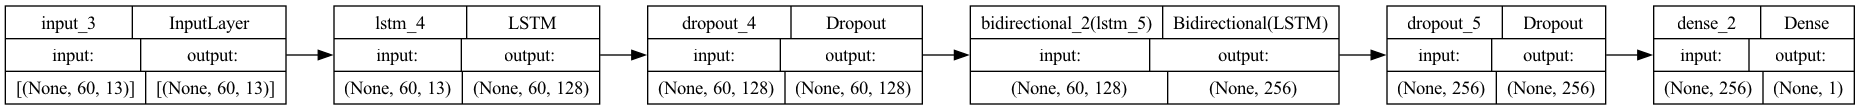

In [74]:
tf.keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [75]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # 너무 크면 튕기고, 작으면 세월아 네월아 합니다.
    loss='binary_crossentropy', # 0 아니면 1 맞히는 거니까!
    metrics=['accuracy']
)

In [76]:
training_record = model.fit(ds, epochs=10)

Epoch 1/10
102/102 [==============================] - 10s 64ms/step - loss: 0.6673 - accuracy: 0.5910
Epoch 2/10
102/102 [==============================] - 6s 62ms/step - loss: 0.6037 - accuracy: 0.6763
Epoch 3/10
102/102 [==============================] - 6s 61ms/step - loss: 0.5316 - accuracy: 0.7375
Epoch 4/10
102/102 [==============================] - 6s 56ms/step - loss: 0.4837 - accuracy: 0.7669
Epoch 5/10
102/102 [==============================] - 6s 56ms/step - loss: 0.4308 - accuracy: 0.8026
Epoch 6/10
102/102 [==============================] - 6s 57ms/step - loss: 0.4001 - accuracy: 0.8171
Epoch 7/10
102/102 [==============================] - 6s 59ms/step - loss: 0.3580 - accuracy: 0.8375
Epoch 8/10
102/102 [==============================] - 6s 60ms/step - loss: 0.3299 - accuracy: 0.8552
Epoch 9/10
102/102 [==============================] - 6s 57ms/step - loss: 0.3052 - accuracy: 0.8692
Epoch 10/10
102/102 [==============================] - 6s 59ms/step - loss: 0.2835 - accur

In [ ]:
# model.save('model-tabular-playground-series-apr-2022')
reloaded_model = tf.keras.models.load_model('model-tabular-playground-series-apr-2022')

INFO:tensorflow:Assets written to: model-tabular-playground-series-apr-2022/assets


INFO:tensorflow:Assets written to: model-tabular-playground-series-apr-2022/assets


In [ ]:
test = pd.read_csv('tabular-playground-series-apr-2022/test.csv', skiprows=1, header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,25968,684,0,2.427357,19.639706,1.0,-1.466372,-1.289973,-4.207928,2.486339,-2.493893,8.0,-1.123555,-1.673048,10.980453,0.419011
1,25968,684,1,-4.950541,-21.747899,1.0,0.983186,-0.569053,1.845924,-3.887978,1.727481,-2.9,0.395231,-0.882233,-1.871399,-0.008525
2,25968,684,2,1.136012,-10.756303,1.0,1.016814,0.964157,2.454749,0.312386,1.154198,-5.6,1.114162,1.525273,-11.584362,0.139812
3,25968,684,3,0.806028,6.504202,1.0,-0.179646,0.969221,-1.035153,-0.457195,0.254962,-2.7,-0.588873,0.608761,-4.241770,-0.462916
4,25968,684,4,1.288253,5.552521,1.0,-0.493805,-1.036124,-1.126402,2.008197,-0.730534,0.0,0.899566,-1.259615,-0.472222,-0.121483


In [80]:
features = [i for i in range(3,16)]
grouped = test.groupby(0)[features].apply(lambda x: x.values)
test_np = np.stack(grouped.values)
test_tensor = tf.convert_to_tensor(test_np, dtype=tf.float32)

In [ ]:
from sklearn.metrics import roc_auc_score

test_pred = reloaded_model.predict(test_tensor)

382/382 [==============================] - 6s 13ms/step


In [82]:
print(test_pred)

[[0.9895013 ]
 [0.9579969 ]
 [0.00168075]
 ...
 [0.23807205]
 [0.0013722 ]
 [0.5746261 ]]
